In [10]:
pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 9.7 MB/s  0:00:01m 8.8 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [14]:
from ultralytics import YOLO
from pathlib import Path
import pandas as pd

import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image
import cv2

# Model

In [2]:
model = YOLO("yolo11m.pt")

# Data

In [3]:
photos_dir = Path("../data/raw_photo_sample")
image_paths = list(photos_dir.glob("*.jpg"))

In [4]:
print(len(image_paths))

71


# Predict

In [7]:
results = model.predict(
    source=str(photos_dir),
    conf = 0.25,
    save=True
)


image 1/71 /Users/himynameisartem/Documents/Development/ML/Renovation_calculator_CV/notebooks/../data/raw_photo_sample/IM5A4169.jpg: 448x640 12 birds, 2 potted plants, 1 bed, 1 refrigerator, 2 vases, 164.1ms
image 2/71 /Users/himynameisartem/Documents/Development/ML/Renovation_calculator_CV/notebooks/../data/raw_photo_sample/IM5A4174.jpg: 640x448 12 birds, 2 potted plants, 1 bed, 2 vases, 127.9ms
image 3/71 /Users/himynameisartem/Documents/Development/ML/Renovation_calculator_CV/notebooks/../data/raw_photo_sample/IM5A4176.jpg: 640x448 4 birds, 2 kites, 1 potted plant, 1 bed, 2 vases, 129.3ms
image 4/71 /Users/himynameisartem/Documents/Development/ML/Renovation_calculator_CV/notebooks/../data/raw_photo_sample/IM5A4178.jpg: 448x640 1 potted plant, 1 bed, 1 tv, 1 vase, 121.7ms
image 5/71 /Users/himynameisartem/Documents/Development/ML/Renovation_calculator_CV/notebooks/../data/raw_photo_sample/IM5A4180.jpg: 448x640 1 chair, 1 bed, 1 tv, 1 remote, 2 books, 2 vases, 126.6ms
image 6/71 /Use

In [8]:
rows = []

for result in results:
    image_name = Path(result.path).name

    for box in result.boxes:
        cls_id = int(box.cls[0])
        label = model.names[cls_id]
        confidence = float(box.conf[0])
        x1, y1, x2, y2 = box.xyxy[0].tolist()

        rows.append({
            "image": image_name,
            "label": label,
            "confidence": round(confidence, 3),
            "x1": round(x1, 1),
            "y1": round(y1, 1),
            "x2": round(x2, 1),
            "y2": round(y2, 1),
        })

predictions_df = pd.DataFrame(rows)
predictions_df.head(20)

,image,label,confidence,x1,y1,x2,y2
0,IM5A4169.jpg,bed,0.934,337.7,1332.3,3514.1,2641.1
1,IM5A4169.jpg,bird,0.675,1674.2,819.2,1777.4,894.0
2,IM5A4169.jpg,vase,0.573,1194.6,1565.9,1281.3,1706.5
3,IM5A4169.jpg,bird,0.548,1854.3,779.4,1929.6,830.1
4,IM5A4169.jpg,bird,0.545,2116.7,857.5,2213.3,928.0
5,IM5A4169.jpg,bird,0.515,1522.2,655.2,1628.1,763.2
6,IM5A4169.jpg,refrigerator,0.458,2.5,68.2,443.3,2470.8
7,IM5A4169.jpg,vase,0.454,2699.3,1527.6,2783.2,1659.7
8,IM5A4169.jpg,bird,0.386,1687.5,607.2,1798.3,704.1
9,IM5A4169.jpg,bird,0.380,1921.6,652.2,2000.6,702.4


In [9]:
predictions_df["label"].value_counts()

label
vase             90
bird             66
chair            47
potted plant     39
bottle           37
tv               20
couch            20
bed              17
book             14
dining table     13
sink             11
toilet            9
bowl              7
teddy bear        6
oven              6
microwave         5
toothbrush        5
refrigerator      4
keyboard          4
kite              3
remote            3
horse             3
orange            3
toaster           3
airplane          2
dog               2
cup               2
traffic light     1
bench             1
apple             1
mouse             1
Name: count, dtype: int64

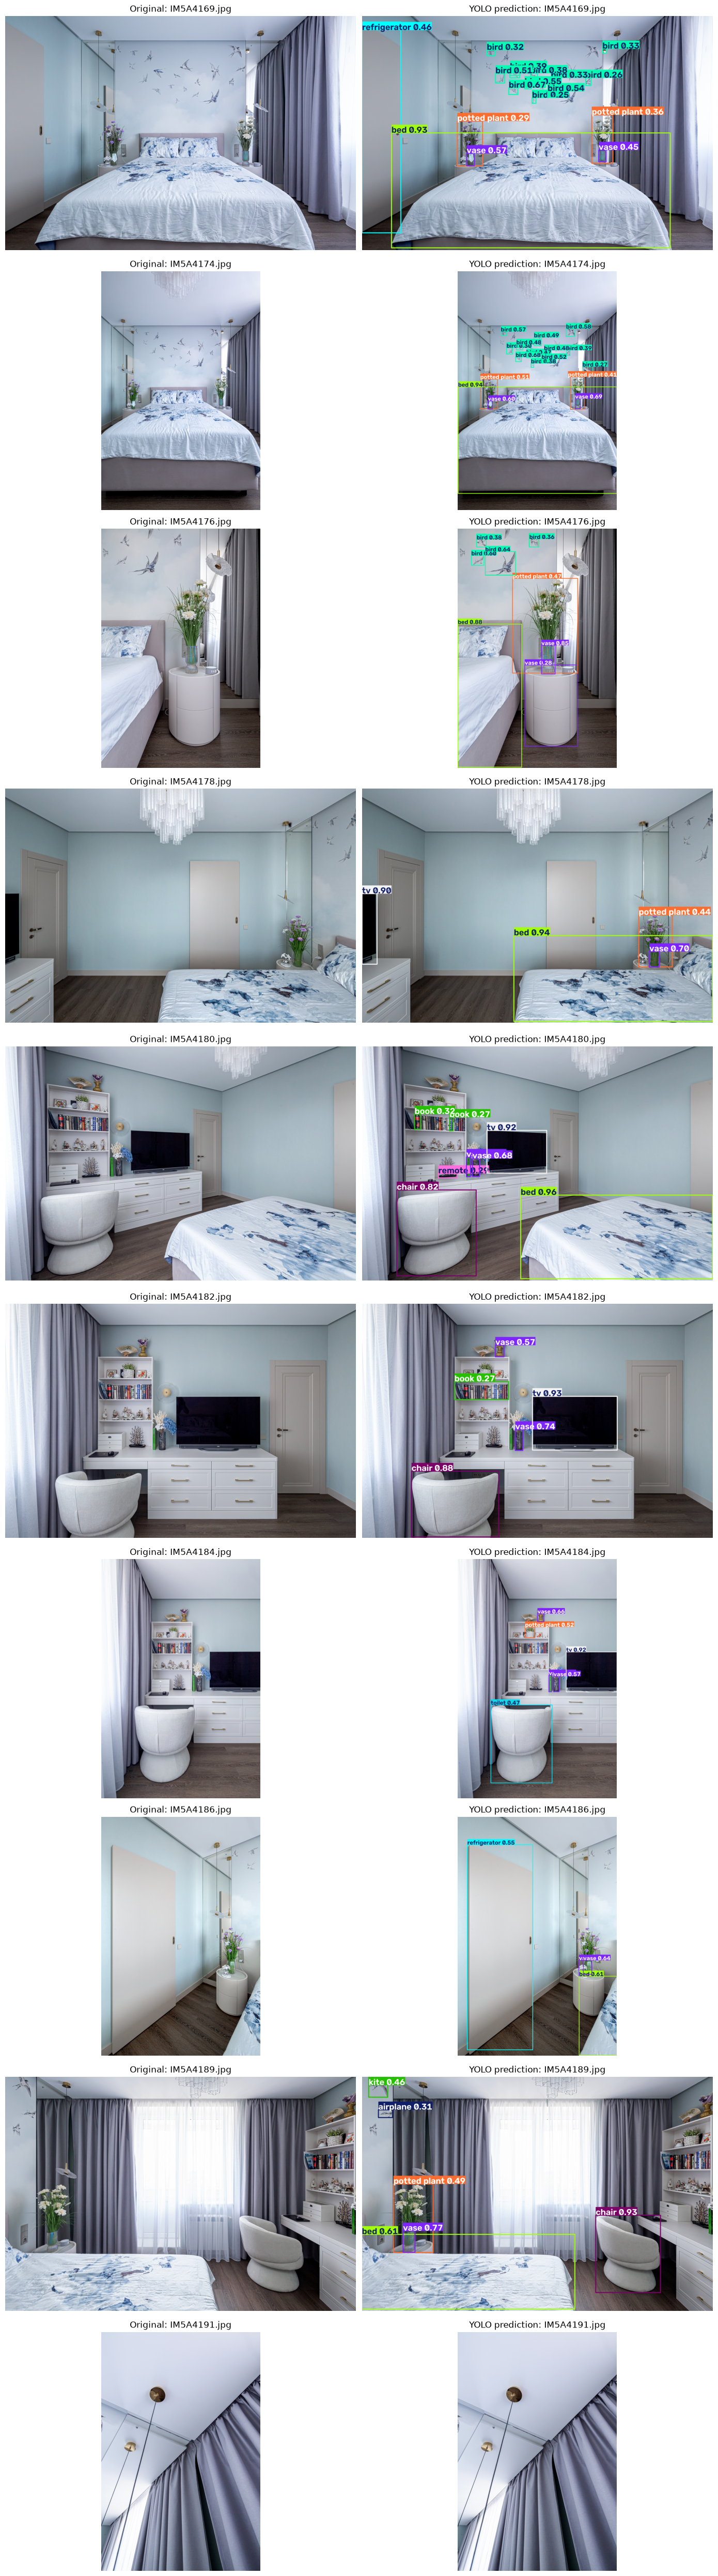

In [15]:
rows_count = min(10, len(results))

fig, axes = plt.subplots(rows_count, 2, figsize=(14, rows_count * 5))

if rows_count == 1:
    axes = [axes]

for i, result in enumerate(results[:rows_count]):
    original_path = Path(result.path)
    original_img = Image.open(original_path)

    predicted_img = result.plot()
    predicted_img = cv2.cvtColor(predicted_img, cv2.COLOR_BGR2RGB)

    axes[i][0].imshow(original_img)
    axes[i][0].set_title(f"Original: {original_path.name}")
    axes[i][0].axis("off")

    axes[i][1].imshow(predicted_img)
    axes[i][1].set_title(f"YOLO prediction: {original_path.name}")
    axes[i][1].axis("off")

plt.tight_layout()
plt.show()